## ReAct Agent Architecture

![re-act-agent-architecture](./flowcharts/3-re-act-agent-architecture.svg)

### Initalize model

In [3]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

load_dotenv()

model = init_chat_model(
    model = "groq:qwen/qwen3.6-27b"
)

### Create tavily web search tool

In [5]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_result=2)

tool.invoke("What is langgraph ?")

{'query': 'What is langgraph ?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. [...] langgraph: Framework for building graph-based AI workflows.\n langchain: Popular toolkit for LLM-powered AI applications.\n google-generativeai: Google’s API for Generative AI (Gemini models).\n\n Python  ````\n! pip install langgraph langchain google - generativeai\n```` \n\n### Step 2: Setup Gemini API [...] ## Building a Simple Chatbot with LangGraph\n\nLangGraph makes it easy to build structured, stateful applications like chatbots. In this example we’ll learn ho

### Custom function

In [6]:
def multiply(a: int, b:int) -> int:
    """
    Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [7]:
tools = [tool, multiply]

In [8]:
llm_with_tools = model.bind_tools(tools)

In [9]:
print(llm_with_tools)

bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.4', 'langchain': '1.3.15'}}, client=<groq.resources.chat.completions.Completions object at 0x10fbdb620>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10fd98440>, model_name='qwen/qwen3.6-27b', model_kwargs={}, groq_api_key=SecretStr('**********')) kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.', 'parameters': {'properties': {'query': {'description': 'Search query to look up', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type':

### Creat state graph

In [11]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display

In [12]:
class State(TypedDict):
    # Messages have the type "list", the 'add_messages' function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages in to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

### Node definition

In [13]:
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

### Graph

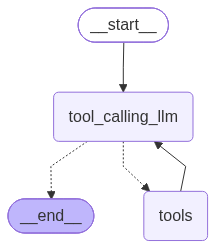

In [ ]:
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

### Add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm", 
    # If the latest message (result) from assitant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)

builder.add_edge("tools", "tool_calling_llm")

### compile the graph
graph = builder.compile()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    raise e

### Complex Query 1 : custom tool call

In [22]:
response = graph.invoke({"messages": "What is 5 multiply by 2 and then multiply 10?"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiply by 2 and then multiply 10?
================================== Ai Message ==================================
Tool Calls:
  multiply (hqfff9n7j)
 Call ID: hqfff9n7j
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10
================================== Ai Message ==================================
Tool Calls:
  multiply (5795k6byw)
 Call ID: 5795k6byw
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: multiply

100
================================== Ai Message ==================================

5 multiplied by 2 is 10, and 10 multiplied by 10 is 100.


### Complex Query 2 : web search tool call and custom tool call

In [23]:
response = graph.invoke({"messages": "give me the recnt ai news and then multiply 5 by 10"})

for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

give me the recnt ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (35s6nnvg8)
 Call ID: 35s6nnvg8
  Args:
    query: recent AI news
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/ai-cybersecurity-incidents-openai-astra-anthropic-kimi-meta-2026-8", "title": "The world's leading AI companies are all struggling to contain their latest models - Business Insider", "score": 0.73914057, "published_date": "Sun, 09 Aug 2026 15:24:36 GMT", "content": "# The world's leading AI companies are all struggling to contain their latest models. They also highlight a growing challenge for the companies b

**Conclusion:**

- With the help of `ReAct` agent architecture we are able to solve problem of complex queries
- Now llm can assist the more than one query and tool call decisions in one go.